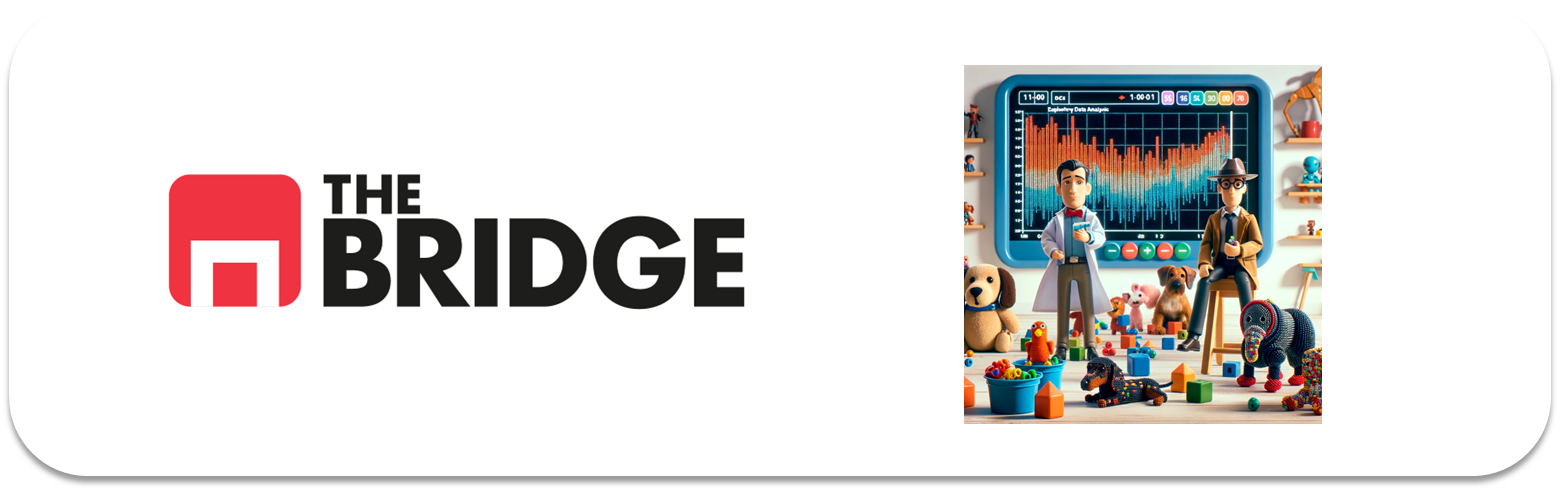

## PRACTICA OBLIGATORIA: **Análisis Multivariante**

* La práctica obligatoria de esta unidad consiste en completar el análisis del dataset del Titanic, dirigido por una serie de preguntas, y de terminar de analizar algunos aspectos del dataset de viajes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from bootcampviztools import plot_categorical_relationship_fin, pinta_distribucion_categoricas
from bootcampviztools import plot_categorical_numerical_relationship, plot_combined_graphs, \
    pinta_distribucion_categoricas, plot_grouped_boxplots, plot_categorical_relationship_fin, plot_grouped_histograms, \
        grafico_dispersion_con_correlacion, bubble_plot


## #1: Titanic

### #1.1

Carga en un dataframe el dataset del titanic, que está en la ruta "./data/titanic.csv".

In [2]:
df_titanic = pd.read_csv("./data/titanic.csv")

In [3]:
df_titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


### #1.2

Deshazte de las columnas "deck", "survived", "pclass" y "embarked" porque no las emplearemos, la primera por su cantidad de nulos y el resto porque son variantes de otras que ya existen y cuyos valores resultan más expresivos a la hora de hacer un análisis. 

In [6]:
df_titanic = df_titanic.drop(columns =["deck", "survived", "embarked"])

### #1.3

Suma las columnas "parch" y "sibsp" para tener el número de parientes de cada pasajero, guarda el resultado en otra columna "family_members", luego deshazte de "parch" y "sibsp"

In [7]:
df_titanic["family_members"] = df_titanic["parch"] + df_titanic["sibsp"]

In [11]:
df_titanic = df_titanic.drop(columns = ["sibsp", "parch"])

### #1.4

Imputa la moda a los valores nulos de "embark_town"

In [12]:
df_titanic["embark_town"].mode()

0    Southampton
Name: embark_town, dtype: str

In [13]:
df_titanic["embark_town"] = df_titanic["embark_town"].fillna("Southampton")

### #1.5

Imputa la media a los valores faltantes de "age", si quieres puedes hacer algo más preciso (por ejemplo considerando además la columna "who")

In [15]:
df_titanic.groupby("sex")["age"].mean()

sex
female    27.915709
male      30.726645
Name: age, dtype: float64

In [22]:
df_titanic["age"] = df_titanic["age"].fillna(
    df_titanic.groupby("sex")["age"].transform("mean"))

In [23]:
df_titanic["age"]

0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    27.915709
889    26.000000
890    32.000000
Name: age, Length: 891, dtype: float64

In [24]:
df_titanic["age"] = round(df_titanic["age"], 0)

In [25]:
df_titanic

,pclass,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members
0,3,male,22.0,7.2500,Third,man,True,Southampton,no,False,1
1,1,female,38.0,71.2833,First,woman,False,Cherbourg,yes,False,1
2,3,female,26.0,7.9250,Third,woman,False,Southampton,yes,True,0
3,1,female,35.0,53.1000,First,woman,False,Southampton,yes,False,1
4,3,male,35.0,8.0500,Third,man,True,Southampton,no,True,0
...,...,...,...,...,...,...,...,...,...,...,...
886,2,male,27.0,13.0000,Second,man,True,Southampton,no,True,0
887,1,female,19.0,30.0000,First,woman,False,Southampton,yes,True,0
888,3,female,28.0,23.4500,Third,woman,False,Southampton,no,False,3
889,1,male,26.0,30.0000,First,man,True,Cherbourg,yes,True,0


### #1.6

Realiza los análisis bivariantes o multivariantes que necesites, así como los test de hipótesis necesarios para contestar a las siguientes preguntas. Nota: utiliza la variable "alive" para saber si un pasajero sobrevivió o no:

1. En términos absolutos, ¿sobrevivieron más hombres, mujeres o niños? ¿Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre el sexo y la supervivencia en el Titanic?¿Y entre ser adulto o ser niño?

2. En términos absolutos, ¿de que clase sobrevivieron más pasajeros?¿ Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre la clase en la que se viajaba y la supervivencia?

3. ¿De qué ciudad sobrevivieron más personas?¿Y porcentualmente de que ciudad sobrevivieron más personas? ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido?

4. ¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento?

5. Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? ¿Qué ocurrió con la persona que más dinero se dejó?

6. Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento. No necesitas aplicar ningún test, muestralo numérica o visualmente.

7. Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?

8. Finalmente, muestra las posibles relaciones entre edad, coste del billete y supervivencia/fallecimiento. ¿Qué puedes decir al respecto?

## RESPUESTAS ##

1. ¿Supervivencia entre hombres y mujeres?¿Relación estadísticamente significativa entre ser hombre o mujer o adulto o niño y sobrevivir?

In [32]:
lista_categoricas = ["sex", "embark_town", "alive", "class", "who", "alone", "adult_male"]

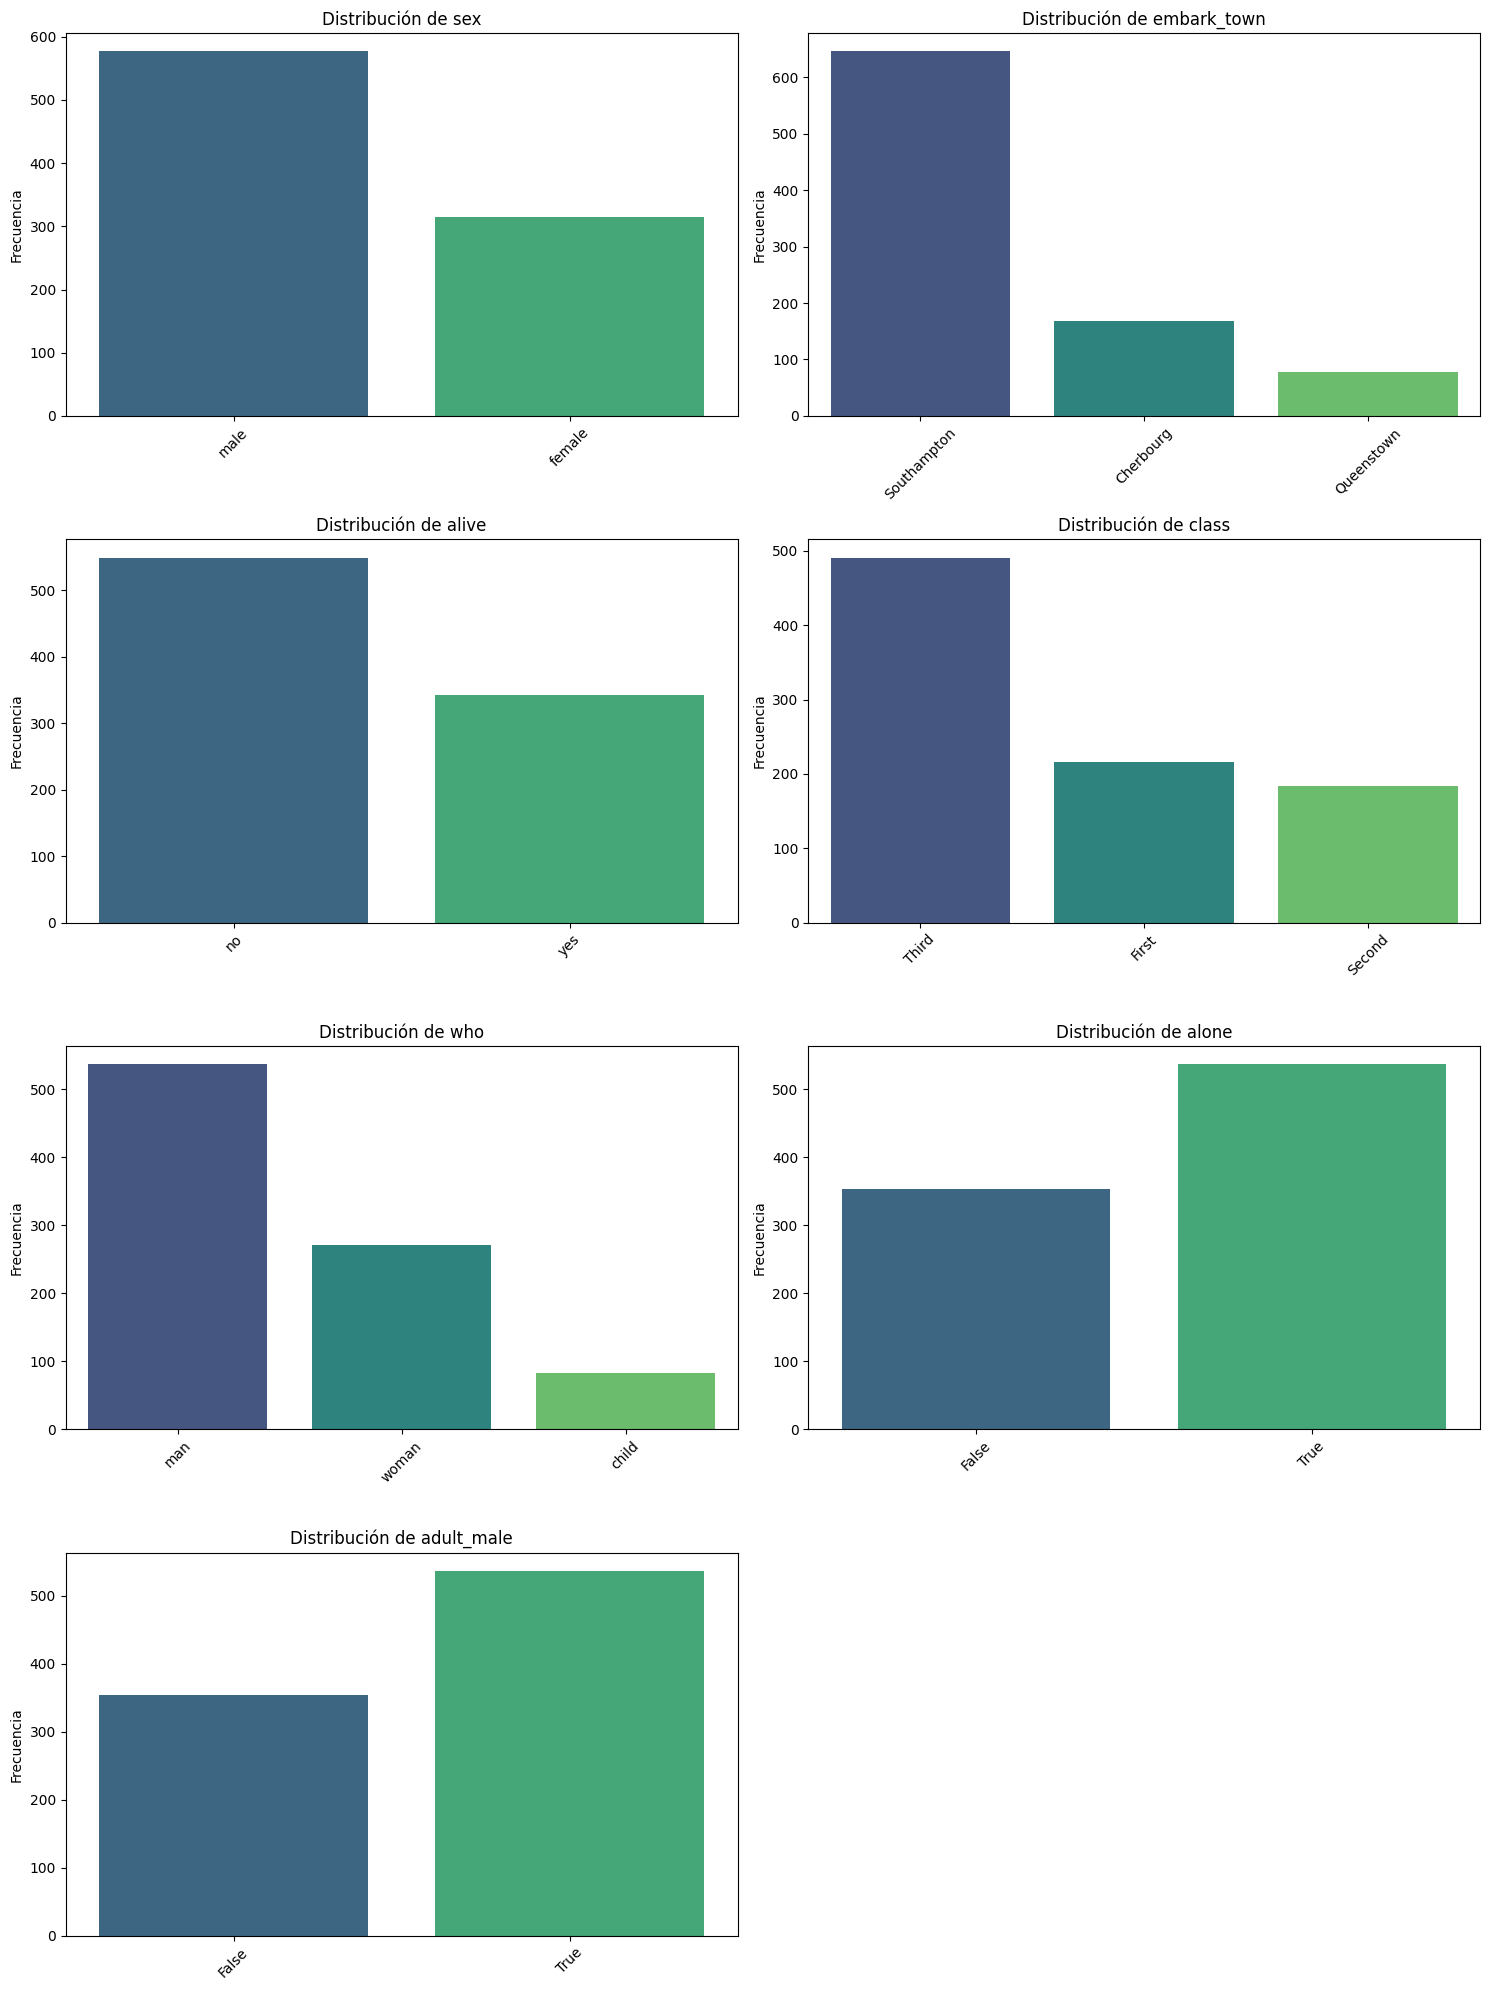

In [33]:
pinta_distribucion_categoricas(df_titanic, lista_categoricas)

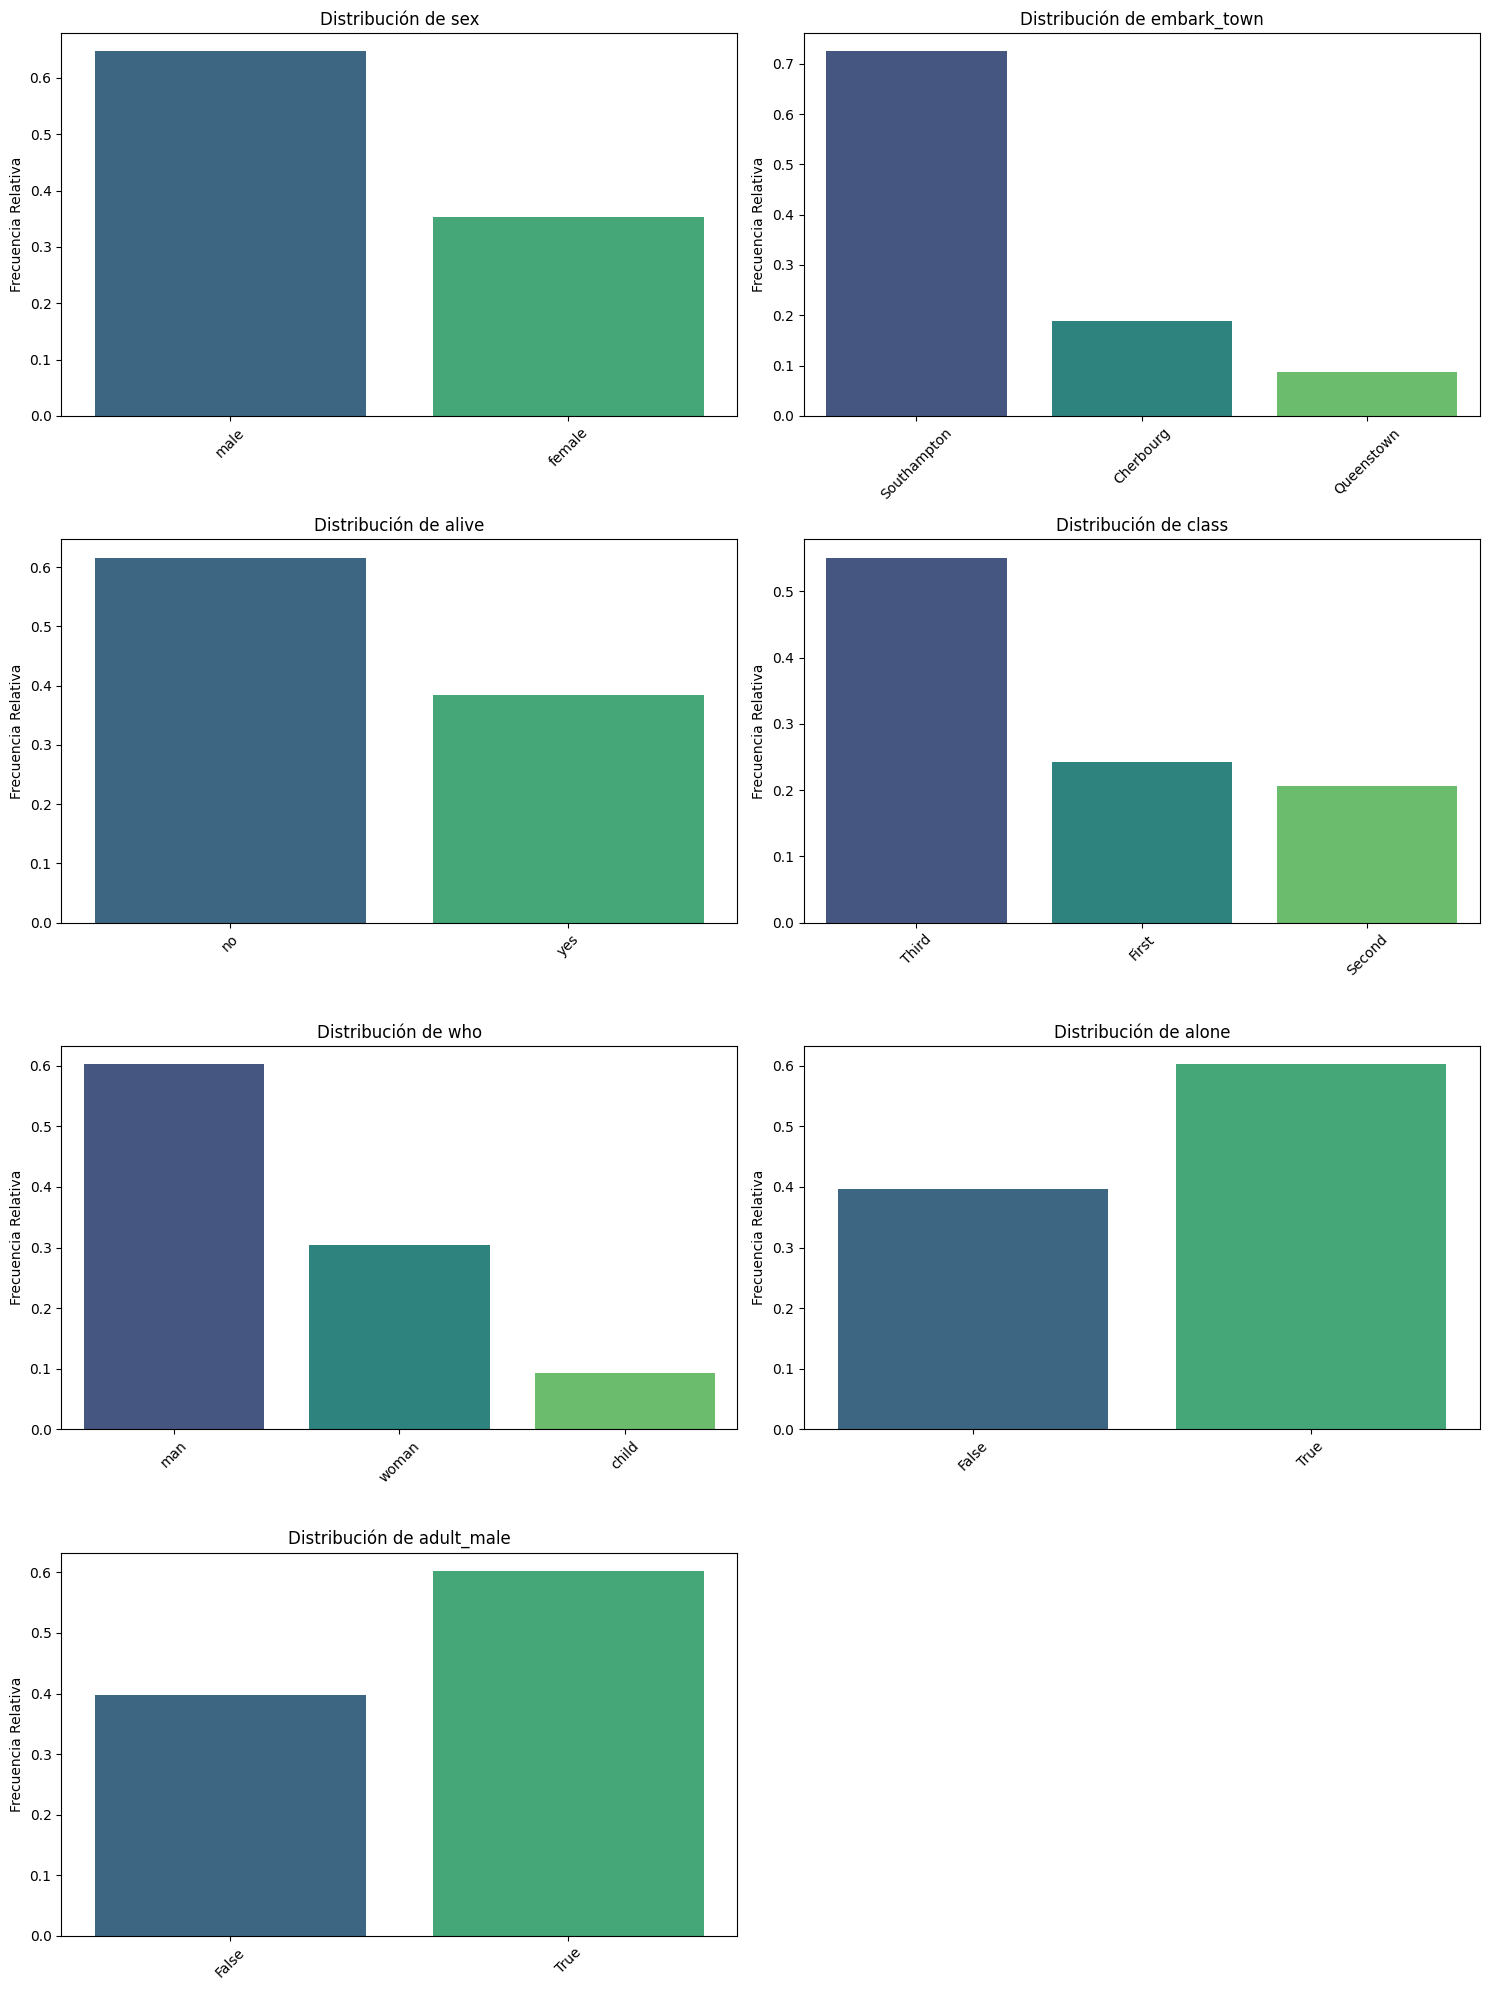

In [35]:
pinta_distribucion_categoricas(df_titanic, lista_categoricas, relativa= True)

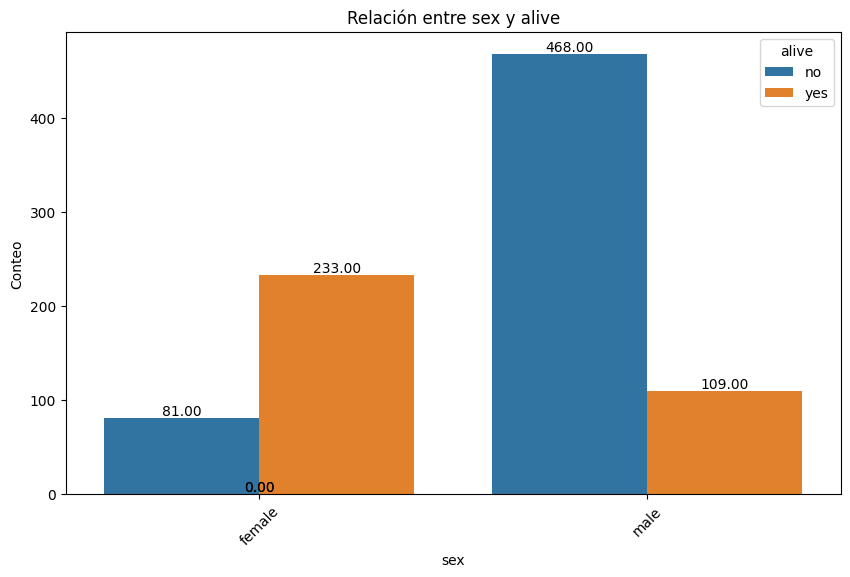

In [37]:
plot_categorical_relationship_fin(df_titanic, "sex", "alive",show_values= True)

In [38]:
tabla_contingencia = pd.crosstab(df_titanic['sex'], df_titanic['alive'])

tabla_contingencia


alive,no,yes
sex,,
female,81,233
male,468,109


In [39]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)


print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 260.71702016732104
P-Value: 1.1973570627755645e-58
Grados de Libertad: 1
Tabla de Frecuencias Esperadas:
 [[193.47474747 120.52525253]
 [355.52525253 221.47474747]]


**Sí que existe una diferencia significativa entre el sexo y la supervivencia, ya que el p-value del test chi cuadrado es inferior a 0.05.**

In [47]:
df_titanic["who"].value_counts()

who
man      537
woman    271
child     83
Name: count, dtype: int64

In [ ]:
tabla_contingencia2 = pd.crosstab(df_titanic['who'], df_titanic['alive'])

tabla_contingencia2

alive,no,yes
who,,
child,34,49
man,449,88
woman,66,205


In [61]:
chi2, p, dof, expected = chi2_contingency(tabla_contingencia2)


print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 283.923050324233
P-Value: 2.2227620817798914e-62
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[ 51.14141414  31.85858586]
 [330.87878788 206.12121212]
 [166.97979798 104.02020202]]


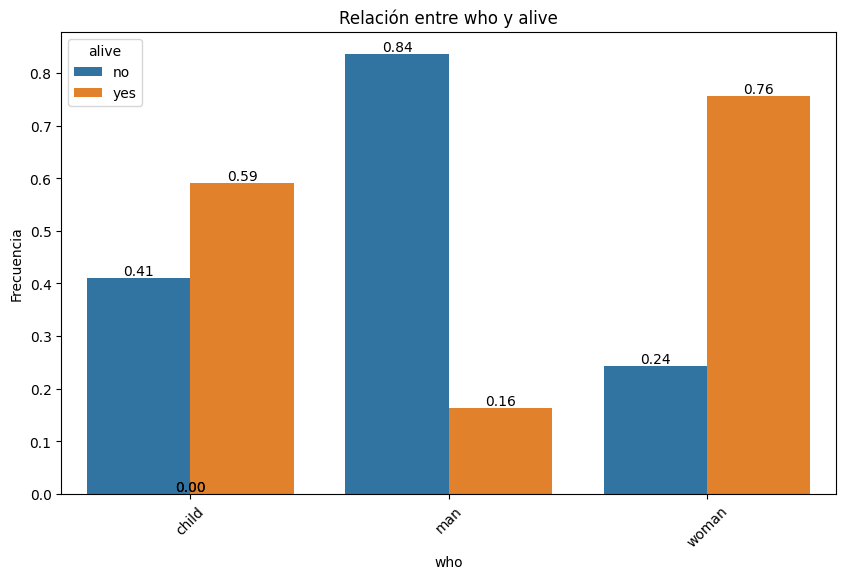

In [52]:
plot_categorical_relationship_fin(df_titanic, "who", "alive",show_values= True, relative_freq = True)

**Como el análisis de chi cuadrado para las variables who y alive tiene un p-valor inferior a 0.05, se rechaza la hipótesis nula de que las variables sean independientes y se acepta la hipótesis alternativa de que están correlacionadas. Faltaría ver en qué niveles se da esta correlación, aunque probablemente se de en mayor probabilidad de supervivencia para muejeres y menor para hombres. En niños no parece que pueda ser estadísticamente significativa la diferencia entre supervivencia y fallecimiento.**

In [62]:
residuos = (tabla_contingencia2 - expected) / np.sqrt(expected)
residuos

alive,no,yes
who,,
child,-2.396957,3.036920
man,6.493718,-8.227475
woman,-7.814524,9.900922


**Se confirma que sobreviven más niños y mujeres de los esperados en caso de independencia de variables y mueren más hombrs de los esperados**

2. ¿Supervivencia dependiendo de clase?: En las frecuencias relativas se ve que más del 50% de los registros corresponden a pasajeros de tercera clase.

In [63]:
tabla_contingencia3 = pd.crosstab(df_titanic['class'], df_titanic['alive'])

tabla_contingencia3

alive,no,yes
class,,
First,80,136
Second,97,87
Third,372,119


In [64]:
chi2, p, dof, expected = chi2_contingency(tabla_contingencia3)


print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 102.88898875696056
P-Value: 4.549251711298793e-23
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[133.09090909  82.90909091]
 [113.37373737  70.62626263]
 [302.53535354 188.46464646]]


In [66]:
residuos = (tabla_contingencia3 - expected) / np.sqrt(expected)
residuos

alive,no,yes
class,,
First,-4.601993,5.830678
Second,-1.537771,1.948340
Third,3.993703,-5.059981


**Sobrevivieron más personas de primera y segunda clase de las esperadas por independencia de variables, mientras que murieron más de tercera clase. El p-valor es menor a 0.05 así que se confirma la correlación entre las dos variables**

3. ¿Correlación entre la ciudad de embarque y la supervivencia?

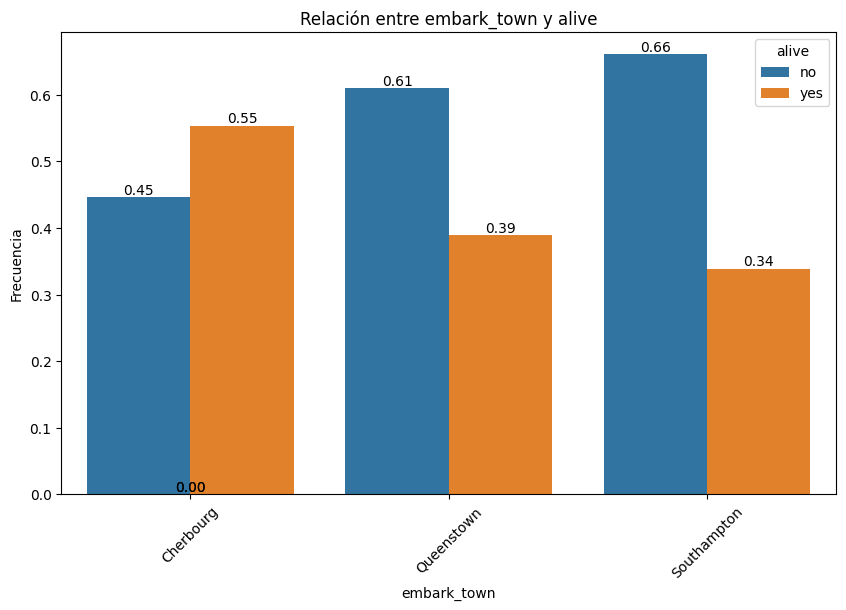

In [68]:
plot_categorical_relationship_fin(df_titanic, "embark_town", "alive",show_values= True, relative_freq = True)

In [70]:
tabla_contingencia4 = pd.crosstab(df_titanic['embark_town'], df_titanic['alive'])

tabla_contingencia4

alive,no,yes
embark_town,,
Cherbourg,75,93
Queenstown,47,30
Southampton,427,219


In [71]:
chi2, p, dof, expected = chi2_contingency(tabla_contingencia4)


print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 25.964452881874784
P-Value: 2.3008626481449577e-06
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[103.51515152  64.48484848]
 [ 47.44444444  29.55555556]
 [398.04040404 247.95959596]]


In [72]:
residuos = (tabla_contingencia4 - expected) / np.sqrt(expected)
residuos

alive,no,yes
embark_town,,
Cherbourg,-2.802681,3.550969
Queenstown,-0.064525,0.081752
Southampton,1.451540,-1.839086


**Hay una mayor supervivencia de los pasajeros de Cherbourg, probablemente porque la mayoría de pasajeros que embarcaron desde allí eran de segunda y primera clase. Queenstown está cerca de no tener realción de dependencia (valor de chi cuadrado próximo a cero) y en relación a Southampton se registran más muertes que las esperadas.**

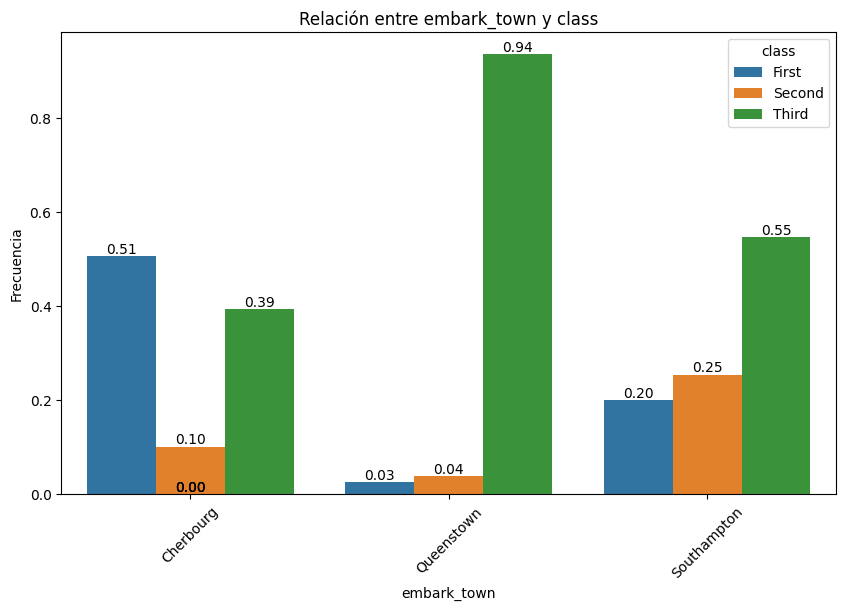

In [73]:
plot_categorical_relationship_fin(df_titanic, "embark_town", "class",show_values= True, relative_freq = True)

**En efecto, la mayor parte de los pasajeros de Cherbourg eran de primera clase (el 51%) y en Southampton el 20%. El mayor porcentaje de pasajeros de tercera clase (94%) embarcó en Queenstown seguido de Southampton (55%). Sin embargo, era en Southampton donde se registraron más muertes y no es el puerto con mayor porcentaje de pasajeros de tercera clase. ¿Probablemente esté relacionado con las secciones del barco que se vieron afectadas en el hundimiento?**

4. ¿Relación entre el precio del billete y la supervivencia?

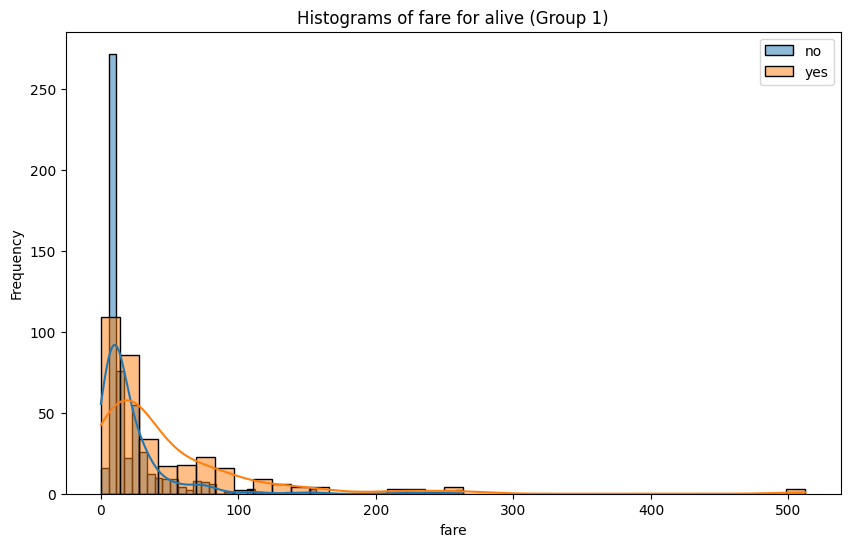

In [75]:
plot_grouped_histograms(df_titanic, cat_col="alive", num_col="fare", group_size=2)

**Hay un pico próximo al límite inferior del precio del billete con una predominancia del valor "No" para la supervivencia. Como no siguen una campana de Gauss, la significancia estadística se comprueba con la prueba U de Mann-Whitney**

In [76]:
from scipy.stats import mannwhitneyu

In [77]:
grupo_a = df_titanic.loc[df_titanic.alive == "yes"]["fare"]
grupo_b = df_titanic.loc[df_titanic.alive == "no"]["fare"]

In [78]:
u_stat, p_valor = mannwhitneyu(grupo_a, grupo_b)

print("Estadístico U:", u_stat)
print("Valor p:", p_valor)

Estadístico U: 129951.5
Valor p: 4.553477179250237e-22


**Sí que hay diferencia estadística (por p-value < 0.05), por lo que existe correlación entre los valores categóricos y numéricos.**

5. ¿Pasajeros que no pagaron billete?¿Qué ocurrió con la persona que más dinero pagó?

In [79]:
df_titanic.describe()

,pclass,age,fare,family_members
count,891.000000,891.000000,891.000000,891.000000
mean,2.308642,29.774411,32.204208,0.904602
std,0.836071,13.015706,49.693429,1.613459
min,1.000000,0.000000,0.000000,0.000000
25%,2.000000,22.000000,7.910400,0.000000
50%,3.000000,30.000000,14.454200,0.000000
75%,3.000000,35.000000,31.000000,1.000000
max,3.000000,80.000000,512.329200,10.000000


In [80]:
df_titanic.loc[df_titanic["fare"] == 0.000000, "who"]

179    man
263    man
271    man
277    man
302    man
413    man
466    man
481    man
597    man
633    man
674    man
732    man
806    man
815    man
822    man
Name: who, dtype: str

In [81]:
df_titanic.loc[df_titanic["fare"] == 0.000000, "alone"]

179    True
263    True
271    True
277    True
302    True
413    True
466    True
481    True
597    True
633    True
674    True
732    True
806    True
815    True
822    True
Name: alone, dtype: bool

In [83]:
(df_titanic["fare"] == 0).sum()

np.int64(15)

In [84]:
df_titanic.loc[df_titanic["fare"] == 0.000000, "class"]

179     Third
263     First
271     Third
277    Second
302     Third
413    Second
466    Second
481    Second
597     Third
633     First
674    Second
732    Second
806     First
815     First
822     First
Name: class, dtype: str

In [85]:
df_titanic.loc[df_titanic["fare"] == 0.000000, "alive"]

179     no
263     no
271    yes
277     no
302     no
413     no
466     no
481     no
597     no
633     no
674     no
732     no
806     no
815     no
822     no
Name: alive, dtype: str

**Los pasajeros con registro de tarifa == 0 se trata de 15 hombres de todas las clases que viajaban solos. Por tanto, probablemente se trate de registros faltantes debido al fallecimiento de los mismos o a errores en los datos proporcionados** 

In [86]:
df_titanic.loc[df_titanic["fare"] == 512.329200, "who"]

258    woman
679      man
737      man
Name: who, dtype: str

In [87]:
df_titanic.loc[df_titanic["fare"] == 512.329200, "class"]

258    First
679    First
737    First
Name: class, dtype: str

In [88]:
df_titanic.loc[df_titanic["fare"] == 512.329200, "alive"]

258    yes
679    yes
737    yes
Name: alive, dtype: str

In [89]:
df_titanic.loc[df_titanic["fare"] == 512.329200, "family_members"]

258    0
679    1
737    0
Name: family_members, dtype: int64

In [90]:
df_titanic.loc[df_titanic["fare"] == 512.329200, "alone"]

258     True
679    False
737     True
Name: alone, dtype: bool

In [91]:
df_titanic.loc[df_titanic["fare"] == 512.329200, "sex"]

258    female
679      male
737      male
Name: sex, dtype: str

**Las tres personas que pagaron la tarifa máxima eran pasajeros de primera clase que sobrevivieron, aunque no son de la misma familia, ya que dos de ellos viajaban solos (una mujer y un hombre)**

6. ¿Relación absoluta y relativa entre la ciudad de embarque, el dinero pagado y la supervivencia?

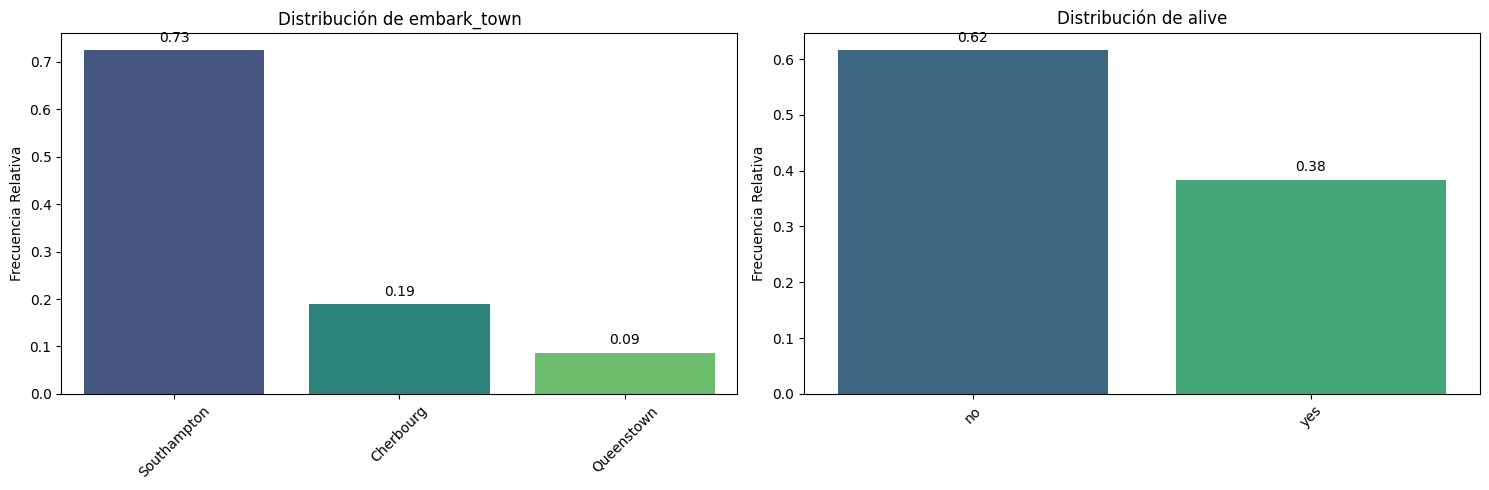

In [92]:
pinta_distribucion_categoricas(df_titanic, ["embark_town", "alive"], relativa= True, mostrar_valores= True) 

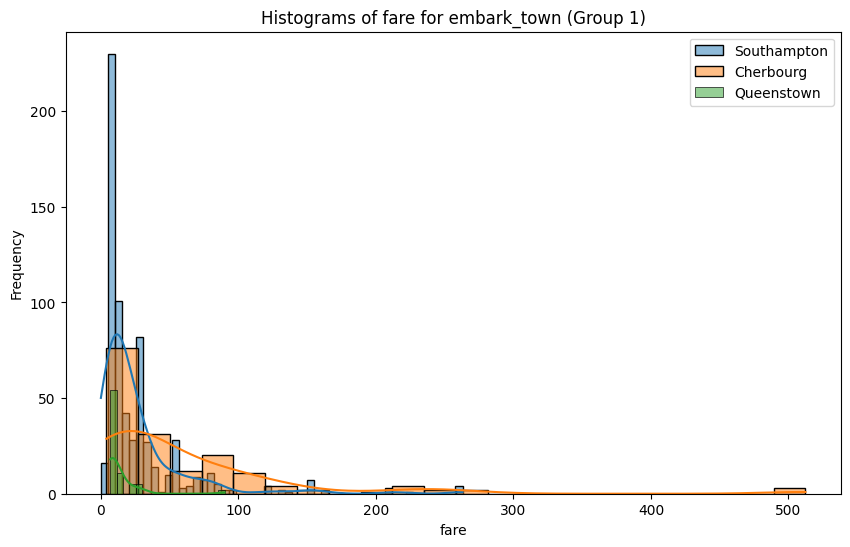

In [93]:
plot_grouped_histograms(df_titanic, cat_col="embark_town", num_col="fare", group_size=3)

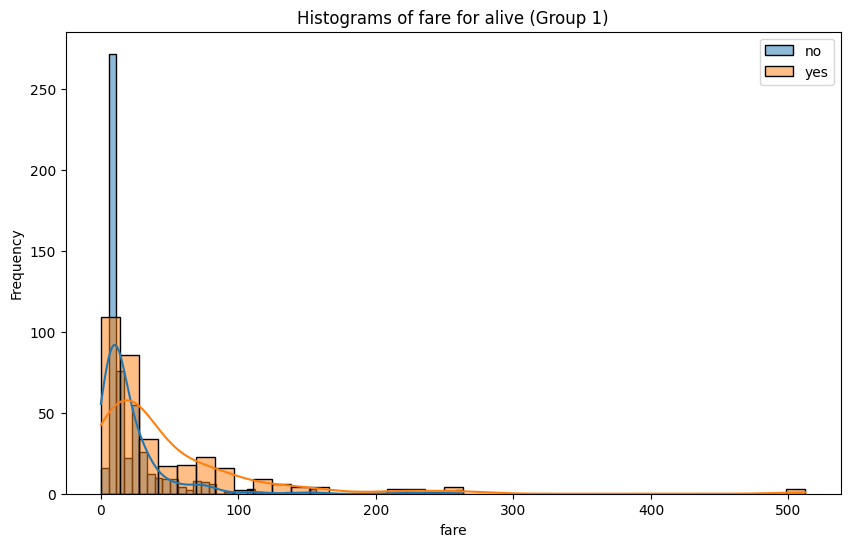

In [94]:
plot_grouped_histograms(df_titanic, cat_col="alive", num_col="fare", group_size=2)

**Donde se pagaron los billetes más caros fue en Cherbourg, que es donde se registraron más pasajeros de primera clase. En Southampton se pagó menos precio por billete**

7. ¿Qué agrupación de clase y edad sobrevivió más?

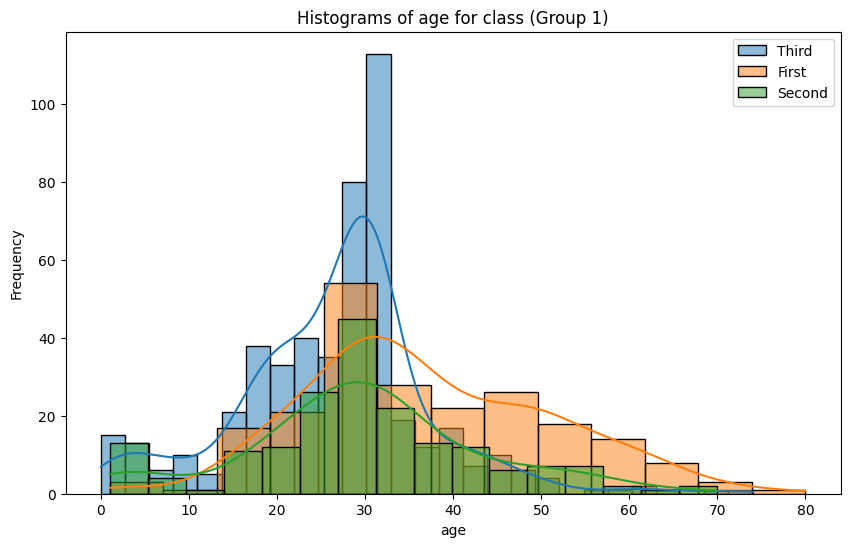

In [95]:
plot_grouped_histograms(df_titanic, cat_col="class", num_col="age", group_size=3)

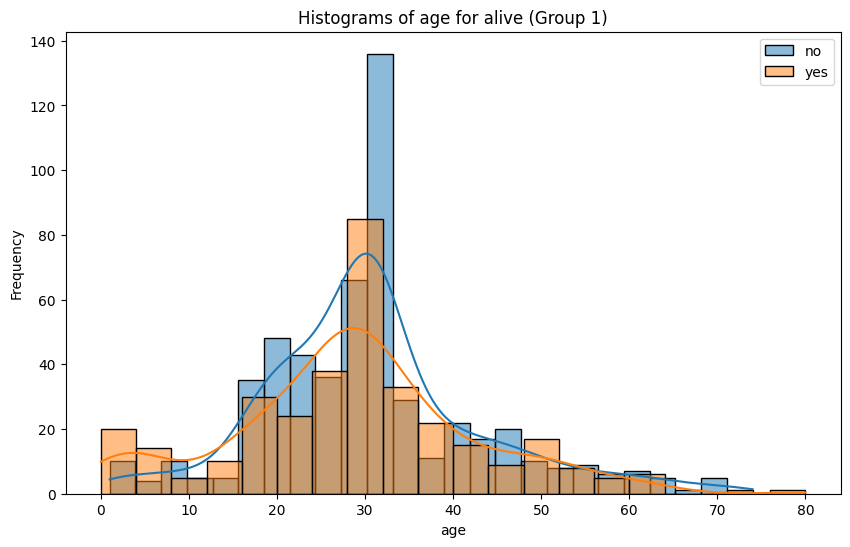

In [96]:
plot_grouped_histograms(df_titanic, cat_col="alive", num_col="age", group_size=2)

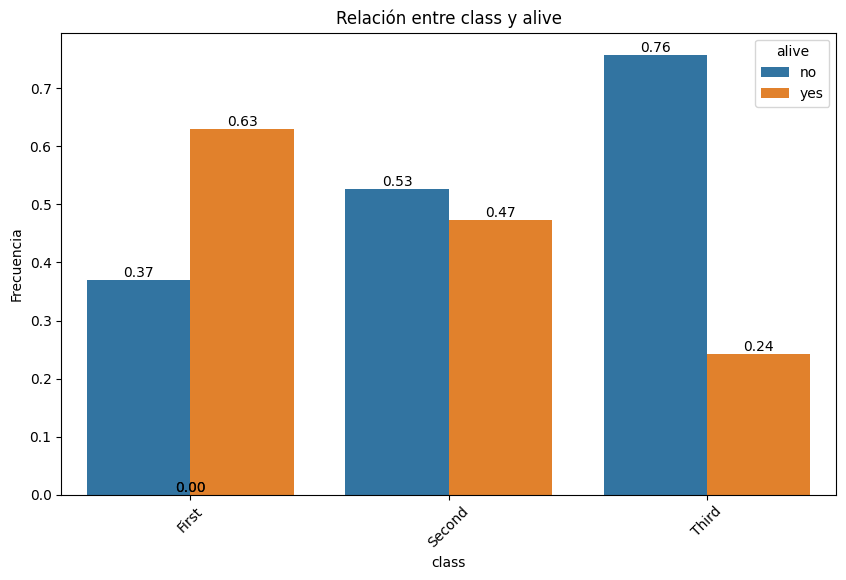

In [98]:
plot_categorical_relationship_fin(df_titanic, "class", "alive",show_values= True, relative_freq= True)

**Se registran más supervivientes para pasajeros de 30 años en todas las clases.**

8. Relación entre edad, coste del billete y supervivencia

In [99]:
from scipy import stats

In [100]:
col_directora = "alive"
col_1 = "fare"
col_2 = "age"
diccionario_multivariante = {}
for valor in df_titanic[col_directora].unique():
    diccionario_multivariante[valor] = df_titanic.loc[df_titanic[col_directora] == valor,[col_2,col_1]]

Respuesta no:


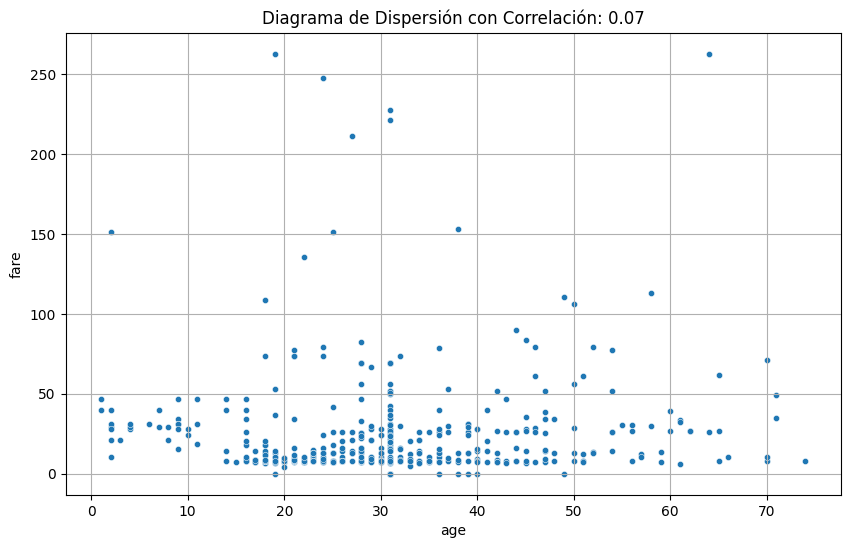

Respuesta yes:


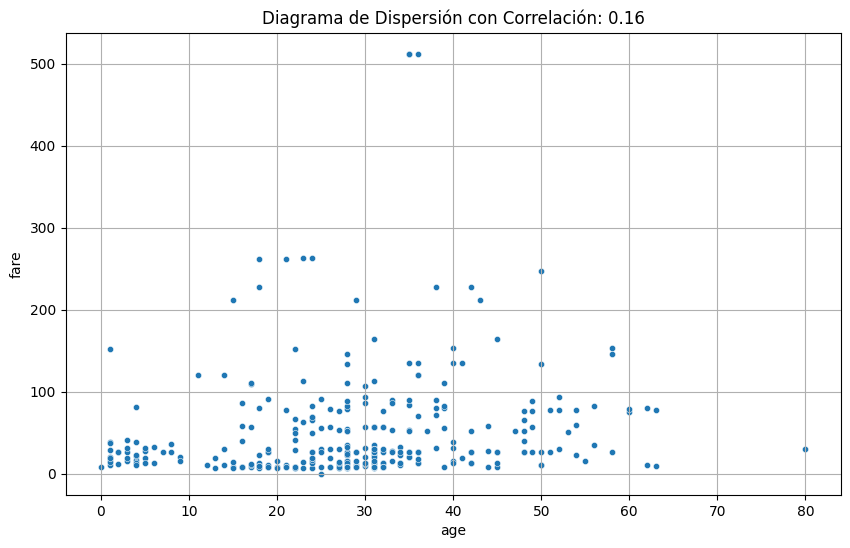

In [101]:
for valor,df_datos in diccionario_multivariante.items():
    print(f"Respuesta {valor}:")
    grafico_dispersion_con_correlacion(df_datos,col_2,col_1, tamano_puntos=20, mostrar_correlacion= True)

**Ni para los supervivientes ni para los fallecidos se observa una correlación en el diagrama de dispersión, por lo que el precio del billete no depende de la edad y esa relación no afecta a la supervivencia**

## #EXTRA: Viajes

El objetivo en este caso no es tanto hacer un montón de análisis sino de completar lo que quedó pendiente en el workout y de entender cómo de un dataset podemos obtener preguntas o hipótesis interesantes (si las hay)

### #EXTRA.1 

Carga el dataset de viajes del mes de junio. Repite el análisis bivariante entre las variables "Aircompany" e "Ingresos", mostrando previamente los viajes por compañía aérea. ¿Qué situación llamativa nos surgió? (Ten en cuenta que somos el departamenteo de DataScience de TabarAir)

### #EXTRA.2

Repite el análisis multivariante entre "ingresos","distancias" y "consumo_kg". ¿Qué veíamos que parecía también muy prometedor?

### #EXTRA.3

Crea una variable categorica "cat_vuelo" a partir de distancias, escoge los rangos de las categorías basándote en la distribución de valores de "distancia" (sugerencia entre 3 y 4 categorías). Extra: Reaiza ahora otra vez el análisis multivariante "cat_vuelo", "ingresos", "consumo_kg". ¿Ves algo diferente?